In [14]:
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm

import matplotlib.pyplot as plt

from tqdm import tqdm

In [6]:
def collocation_points(*args):
    grids = torch.meshgrid(*args, indexing='ij')
    coordinates = torch.stack(grids, dim=len(args)).reshape(-1, len(args))
    return coordinates

class MyData(torch.utils.data.Dataset):
    def __init__(self, cdata):
        self.cdata = cdata
        self.len  = len(cdata)

    def __len__(self):
        return self.len
    
    def __getitem__(self, index):
        return self.cdata[index]

In [7]:
class LinearBlock(nn.Module):
    def __init__(self, in_feature, out_feature):
        super(LinearBlock, self).__init__()
        self.layer = weight_norm(nn.Linear(in_feature, out_feature), dim=0)

    def forward(self, x):
        x = self.layer(x)
        x = torch.tanh(x)
        return x
    
class MLP(nn.Module):
    def __init__(self, layer_list):
        super(MLP, self).__init__()
        self.input_layer = weight_norm(nn.Linear(layer_list[0], layer_list[1]), dim=0)
        self.hidden_layers = self._make_layer(layer_list[1:-1])
        self.out_layer = nn.Linear(layer_list[-2], layer_list[-1])

    def _make_layer(self, layer_list):
        layers = []
        for i in range(len(layer_list) -1):
            block = LinearBlock(layer_list[i], layer_list[i+1])
            layers.append(block)

        return nn.Sequential(*layers) # 언패킹 연산자 *
    
    def forward(self, x):
        x = torch.tanh(self.input_layer(x))
        x = self.hidden_layers(x)
        x = self.out_layer(x)
        return x
    
def weight_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)

def pinn(layer_list):
    model = MLP(layer_list)
    model.apply(weight_init) # module의 기능, 모든 하위 레이어를 훑으면서 weight_init을 실행
    return model

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

num_hidden = 5
num_nodes = 32

layer_list = [2] + num_hidden*[num_nodes] + [1]
model = pinn(layer_list).to(device)

cuda


In [9]:
def fn(cdata):
    return torch.sin(5*cdata[:, 0]) * torch.cos(5*cdata[:, 1])/20

In [10]:
nx = 20
ny = 20
x = torch.linspace(-1, 1, nx)
y = torch.linspace(-1, 1, ny)
cdata = collocation_points(x, y).to(device)

z = fn(cdata) # 정답지
z = z.reshape(-1, 1)
print(cdata.shape, z.shape)

torch.Size([400, 2]) torch.Size([400, 1])


In [18]:
criterion = nn.MSELoss()
lr = 5e-3
epochs = 5000
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [25]:
loss_graph = []

for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    z_pred = model(cdata)
    loss = criterion(z_pred, z)

    loss.backward()
    optimizer.step()

    loss_graph.append(loss.item())

print(f"mse: {loss_graph[-1]}")
torch.save(model.state_dict(), './params/sierra.pt')

100%|██████████| 5000/5000 [00:39<00:00, 127.25it/s]

mse: 1.055893449120049e-06


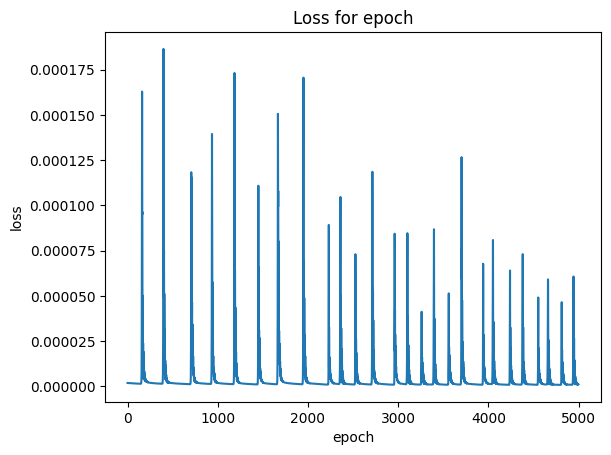

In [26]:
plt.plot(loss_graph)
plt.title("Loss for epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [27]:
model.load_state_dict(torch.load('./params/sierra.pt', map_location=device))

<All keys matched successfully>

In [28]:
nx = 50
ny = 50
x_test = torch.linspace(-1, 1, nx)
y_test = torch.linspace(-1, 1, ny)
cdata_test = collocation_points(x, y).to(device)

z_test = fn(cdata_test)
with torch.no_grad():
    z_pred = model(cdata_test).squeeze()

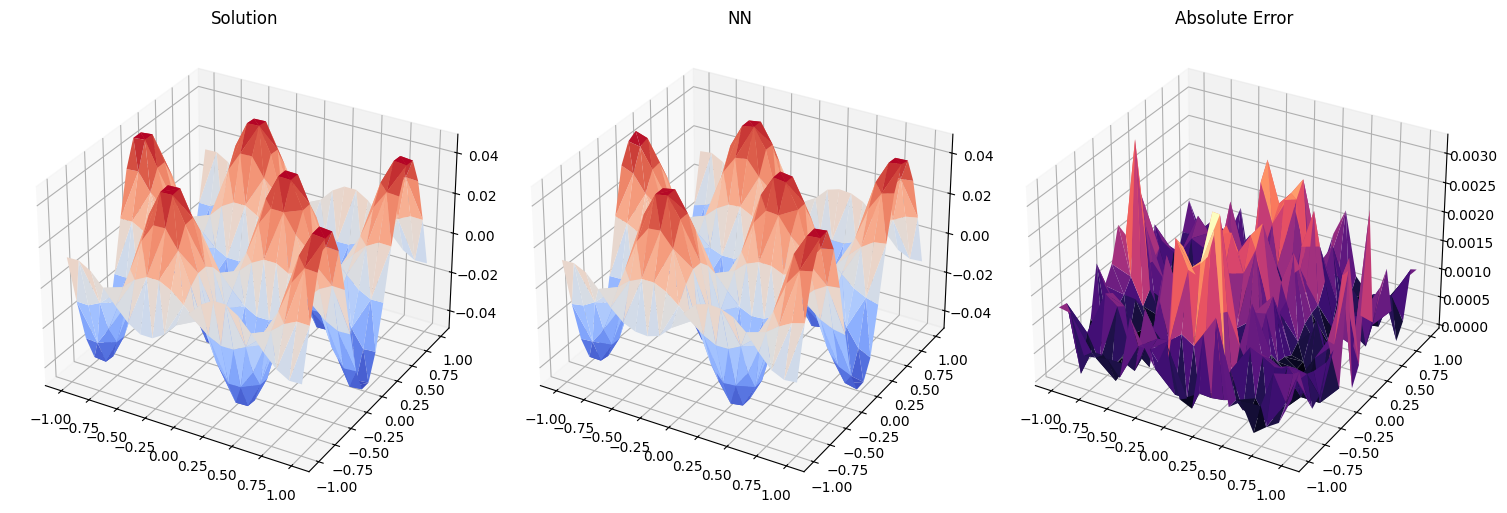

In [32]:
# 실제 물리법칙에 대한 정답지
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(cdata_test.cpu().numpy()[:, 0], cdata_test.cpu().numpy()[:, 1], z_test.cpu().numpy(), cmap='coolwarm')
ax1.set_title("Solution")

# 학습한 모델이 예측한 시험지
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(cdata_test.cpu().numpy()[:, 0], cdata_test.cpu().numpy()[:, 1], z_pred.cpu().numpy(), cmap='coolwarm')
ax2.set_title("NN")

# 채점 결과! 얼마나 차이가 나는가
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(cdata_test.cpu().numpy()[:, 0], cdata_test.cpu().numpy()[:, 1], abs(z_test - z_pred).cpu().numpy(), cmap='magma')
ax3.set_title("Absolute Error")

plt.tight_layout()
plt.show()

# 겉보기에는 거의 똑같은데?